## Imports and Setup

In [1]:
import sys

sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import (
    # Models
    NeuralUCB, NeuralThompson, NeuralEpsilon, NeuralGreedy,
    RewardModelEnsemble,
    # Policies
    LinUCBPolicy, EpsilonGreedyPolicy, BoltzmannPolicy, RandomPolicy, GreedyPolicy,
    # Simulation
    OnlineSimulator, SimulationAgent,
    make_reward_model_agent, make_neural_bandit_agent,
    make_linucb_agent, make_random_agent, make_oracle_agent,
    quick_compare,
    # Pipeline
    FeaturePipeline, load_and_prepare,
    # Data
    TREATMENTS, N_TREATMENTS, IDX_TO_TREATMENT, CONTEXT_FEATURES,
    # Utils
    seed_everything, setup_plotting, timer, save_results,
    TREATMENT_COLORS, ensure_dirs,
)
from src.utils import (
    plot_cumulative_regret, plot_cumulative_reward,
    plot_learning_curves, plot_regret_and_accuracy,
    plot_policy_comparison, plot_action_distribution,
)

seed_everything(42)
setup_plotting()
ensure_dirs()
print("Setup complete")

Setup complete


## Load Data and Prepare Pipelines

In [2]:
df = pd.read_csv("../data/bandit_dataset.csv")

# Scaled pipeline for neural models
pipe_scaled = FeaturePipeline(scale=True, add_interactions=True)
X_train_s, X_test_s, meta_s = pipe_scaled.fit_transform_split(df, test_size=0.2, seed=42)

# Unscaled pipeline for tree-based models
pipe_unscaled = FeaturePipeline(scale=False, add_interactions=True)
X_train_u, X_test_u, meta_u = pipe_unscaled.fit_transform_split(df, test_size=0.2, seed=42)

feature_names = meta_u['feature_names']
input_dim = X_train_s.shape[1]

print(f"Train: {X_train_s.shape[0]} samples, {input_dim} features")
print(f"Pipelines ready: scaled (neural) + unscaled (XGBoost)")

Train: 16000 samples, 25 features
Pipelines ready: scaled (neural) + unscaled (XGBoost)


## Pre-train Models on Offline Data (Warm Start)

In [3]:
# ── XGBoost Reward Model ──
print("Training XGBoost reward model...")
xgb_model = RewardModelEnsemble()
xgb_model.fit(X_train_u, meta_u['a_train'], meta_u['y_train'], feature_names=feature_names)

# ── NeuralUCB ──
print("Training NeuralUCB...")
neural_ucb = NeuralUCB(input_dim=input_dim, hidden_dims=[128, 64], alpha=1.0, device="cpu")
neural_ucb.train(X_train_s, meta_s['a_train'], meta_s['y_train'], epochs=50, verbose=False)
for i in range(min(5000, len(X_train_s))):
    neural_ucb.update_covariance(X_train_s[i], int(meta_s['a_train'][i]))

# ── NeuralThompson ──
print("Training NeuralThompson...")
neural_ts = NeuralThompson(input_dim=input_dim, hidden_dims=[128, 64], noise_variance=0.25, device="cpu")
neural_ts.train(X_train_s, meta_s['a_train'], meta_s['y_train'], epochs=50, verbose=False)
for i in range(min(5000, len(X_train_s))):
    neural_ts.update_posterior(X_train_s[i], int(meta_s['a_train'][i]), float(meta_s['y_train'][i]))

print("All models pre-trained")

All models pre-trained


## Build Simulation Agents

In [4]:
agents = []

# 1. Random baseline
agents.append(make_random_agent())

# 2. Oracle upper bound
agents.append(make_oracle_agent())

# 3. XGBoost + Greedy
agents.append(make_reward_model_agent(
    "XGB_Greedy", xgb_model, GreedyPolicy(), pipe_unscaled,
))

# 4. XGBoost + Epsilon-Greedy
agents.append(make_reward_model_agent(
    "XGB_EpsGreedy", xgb_model,
    EpsilonGreedyPolicy(epsilon=0.1, decay=0.999, epsilon_min=0.01),
    pipe_unscaled,
))

# 5. XGBoost + Boltzmann
agents.append(make_reward_model_agent(
    "XGB_Boltzmann", xgb_model,
    BoltzmannPolicy(temperature=0.5, temperature_decay=0.999, temperature_min=0.1),
    pipe_unscaled,
))

# 6. LinUCB (fully online, no pre-training)
linucb = LinUCBPolicy(feature_dim=input_dim, alpha=1.0)
agents.append(make_linucb_agent("LinUCB", linucb))

# 7. NeuralUCB
agents.append(make_neural_bandit_agent("NeuralUCB", neural_ucb, pipe_scaled))

# 8. NeuralThompson
agents.append(make_neural_bandit_agent("NeuralThompson", neural_ts, pipe_scaled))

print(f"Registered {len(agents)} agents:")
for a in agents:
    print(f"  - {a.name}")

Registered 8 agents:
  - random
  - oracle
  - XGB_Greedy
  - XGB_EpsGreedy
  - XGB_Boltzmann
  - LinUCB
  - NeuralUCB
  - NeuralThompson


## Run Online Simulation (10,000 rounds)

In [5]:
N_ROUNDS = 10000

sim = OnlineSimulator(
    n_rounds=N_ROUNDS,
    pipeline=pipe_scaled,
    unscaled_pipeline=pipe_unscaled,
    seed=42,
    log_interval=2000,
)

for agent in agents:
    sim.add_agent(agent)

with timer(f"Online simulation ({N_ROUNDS} rounds)"):
    results = sim.run()

2026-03-14 20:45:07.179 | INFO     | src.utils:timer:437 - [TIMER] Online simulation (10000 rounds): 547.41s


## Simulation Summary Table

In [6]:
summary = sim.get_summary()
print("=" * 70)
print("ONLINE SIMULATION SUMMARY")
print("=" * 70)
print(summary.to_string(index=False))

ONLINE SIMULATION SUMMARY
         agent  total_reward  total_regret  avg_reward  avg_regret  accuracy  Metformin  GLP-1  SGLT-2  DPP-4  Insulin
        oracle      60385.31        -30.78      6.0385     -0.0031    1.0000     0.3319 0.1799  0.2377 0.1733   0.0772
    XGB_Greedy      60300.33         54.20      6.0300      0.0054    0.9527     0.3248 0.1771  0.2500 0.1668   0.0813
 XGB_Boltzmann      60154.67        199.86      6.0155      0.0200    0.9363     0.3216 0.1768  0.2530 0.1663   0.0823
 XGB_EpsGreedy      59779.34        575.19      5.9779      0.0575    0.9417     0.3222 0.1768  0.2491 0.1688   0.0831
NeuralThompson      59548.95        805.58      5.9549      0.0806    0.8589     0.3085 0.1787  0.2643 0.1691   0.0794
     NeuralUCB      59462.96        891.56      5.9463      0.0892    0.8557     0.3002 0.1838  0.2624 0.1735   0.0801
        LinUCB      58618.99       1735.54      5.8619      0.1736    0.7929     0.2999 0.1694  0.3024 0.1506   0.0777
        random      25

## Cumulative Regret Curves

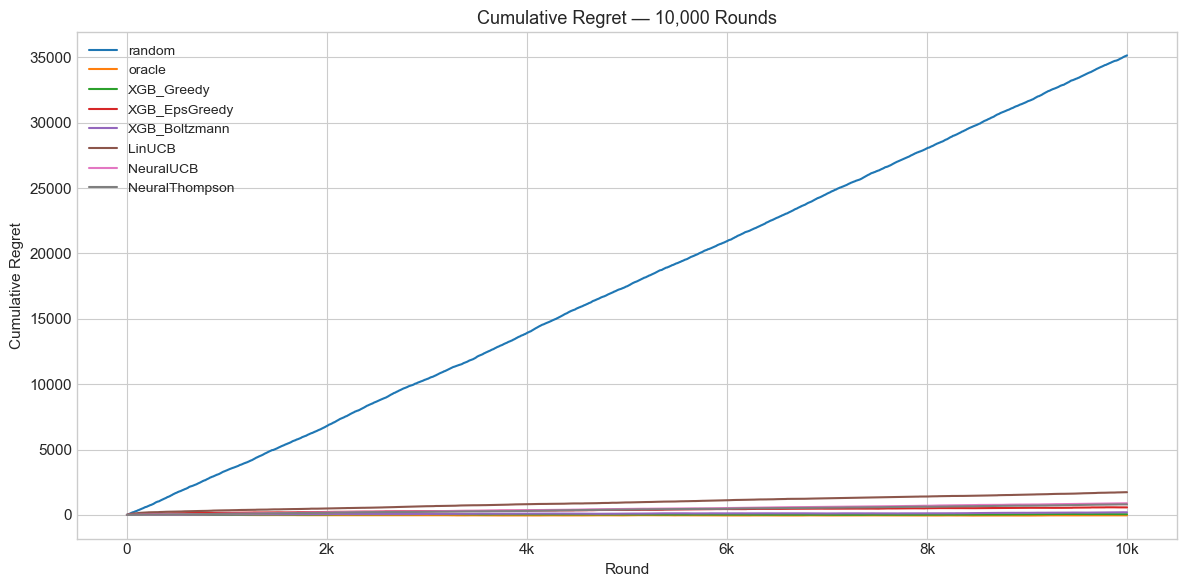

In [7]:
fig = plot_cumulative_regret(
    results,
    title=f"Cumulative Regret — {N_ROUNDS:,} Rounds",
    save_path="../results/cumulative_regret.png",
)
plt.show()

## Cumulative Reward Curves

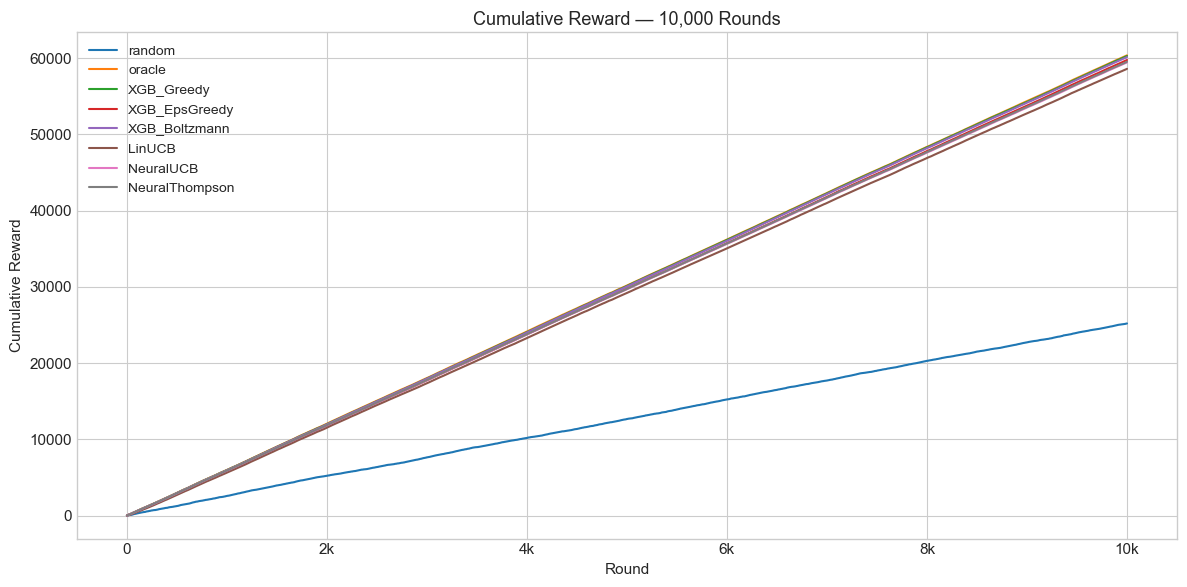

In [8]:
fig = plot_cumulative_reward(
    results,
    title=f"Cumulative Reward — {N_ROUNDS:,} Rounds",
    save_path="../results/cumulative_reward.png",
)
plt.show()

## Learning Curves (Windowed Metrics)

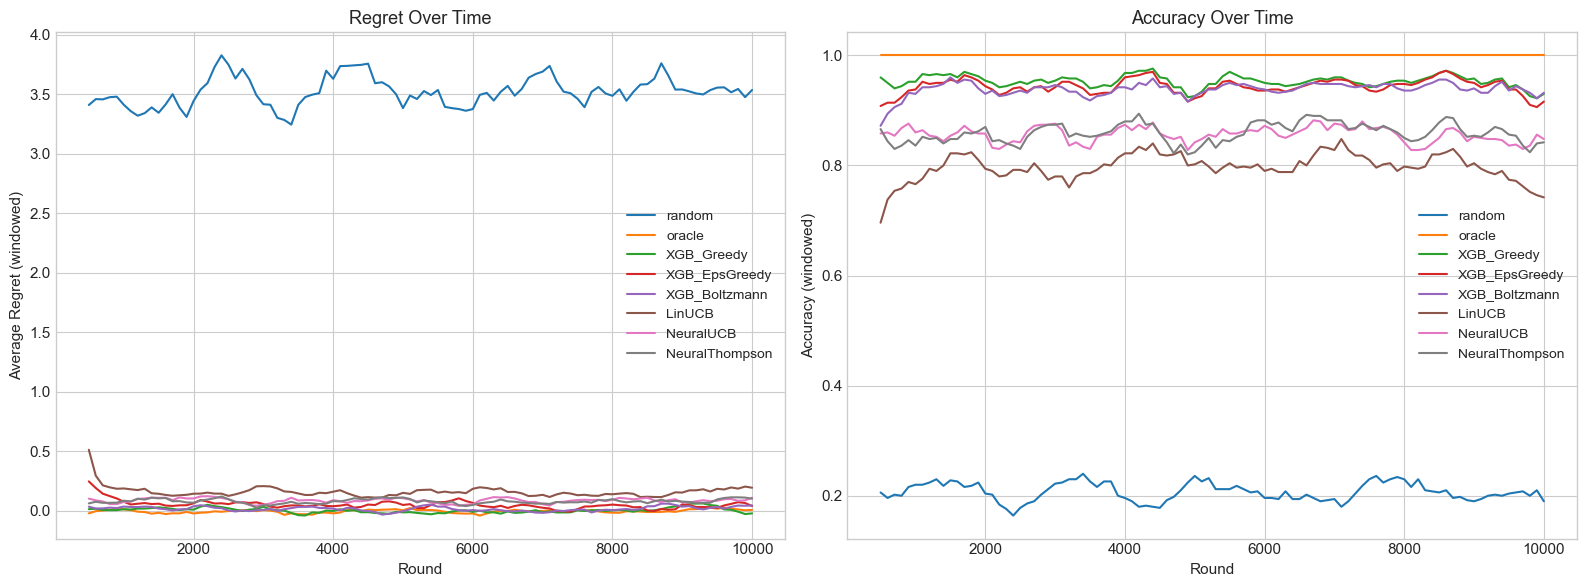

In [9]:
windowed = sim.get_windowed_metrics(window=500)

fig = plot_regret_and_accuracy(
    windowed,
    save_path="../results/learning_curves.png",
)
plt.show()

## Windowed Average Reward

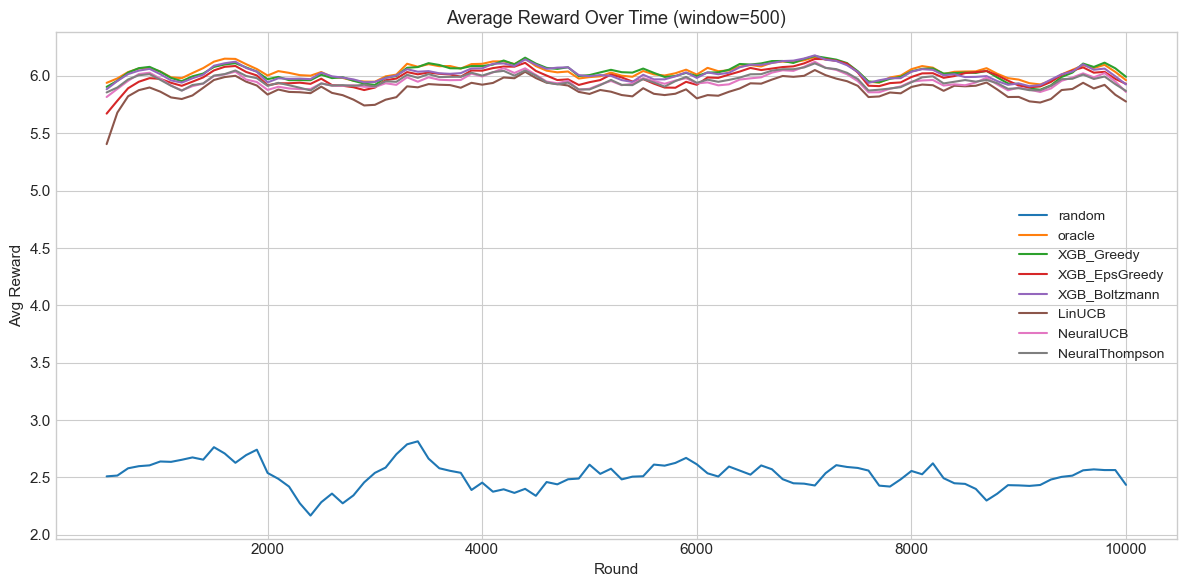

In [10]:
fig = plot_learning_curves(
    windowed,
    metric="avg_reward",
    title="Average Reward Over Time (window=500)",
    save_path="../results/reward_learning_curve.png",
)
plt.show()

## Exploration vs Exploitation — Action Distribution Over Time

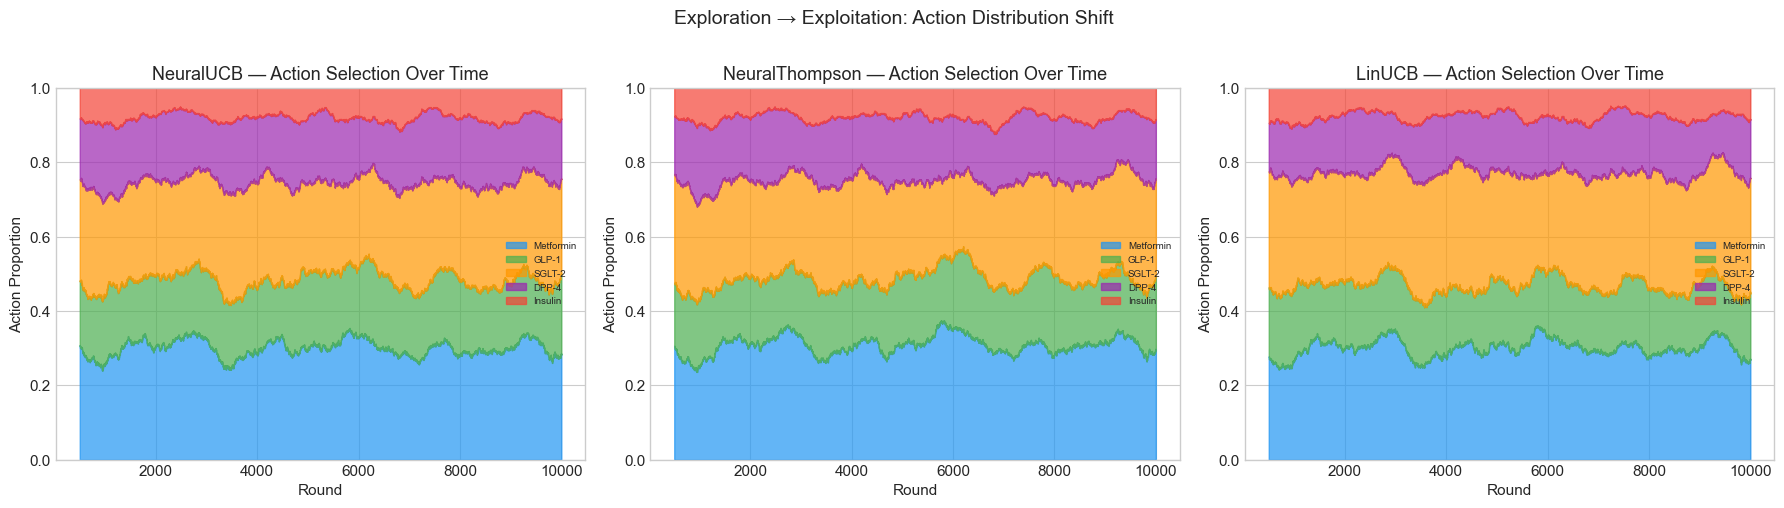

In [11]:
# Track how action distribution changes over time for key agents
key_agents = ["NeuralUCB", "NeuralThompson", "LinUCB"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes.flatten(), key_agents):
    if name not in results:
        continue
    df_r = results[name]
    actions = df_r['action'].values

    # Compute rolling action proportions
    window = 500
    action_props = np.zeros((len(actions) - window + 1, N_TREATMENTS))
    for i in range(len(actions) - window + 1):
        chunk = actions[i:i + window]
        for k in range(N_TREATMENTS):
            action_props[i, k] = (chunk == k).mean()

    rounds = np.arange(window, len(actions) + 1)
    bottom = np.zeros(len(rounds))
    for k in range(N_TREATMENTS):
        ax.fill_between(rounds, bottom, bottom + action_props[:, k],
                        label=TREATMENTS[k], color=TREATMENT_COLORS[TREATMENTS[k]], alpha=0.7)
        bottom += action_props[:, k]

    ax.set_xlabel("Round")
    ax.set_ylabel("Action Proportion")
    ax.set_title(f"{name} — Action Selection Over Time")
    ax.set_ylim(0, 1)
    ax.legend(loc='center right', fontsize=7)

plt.suptitle("Exploration → Exploitation: Action Distribution Shift", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Accuracy Over Time — Who Learns Fastest?

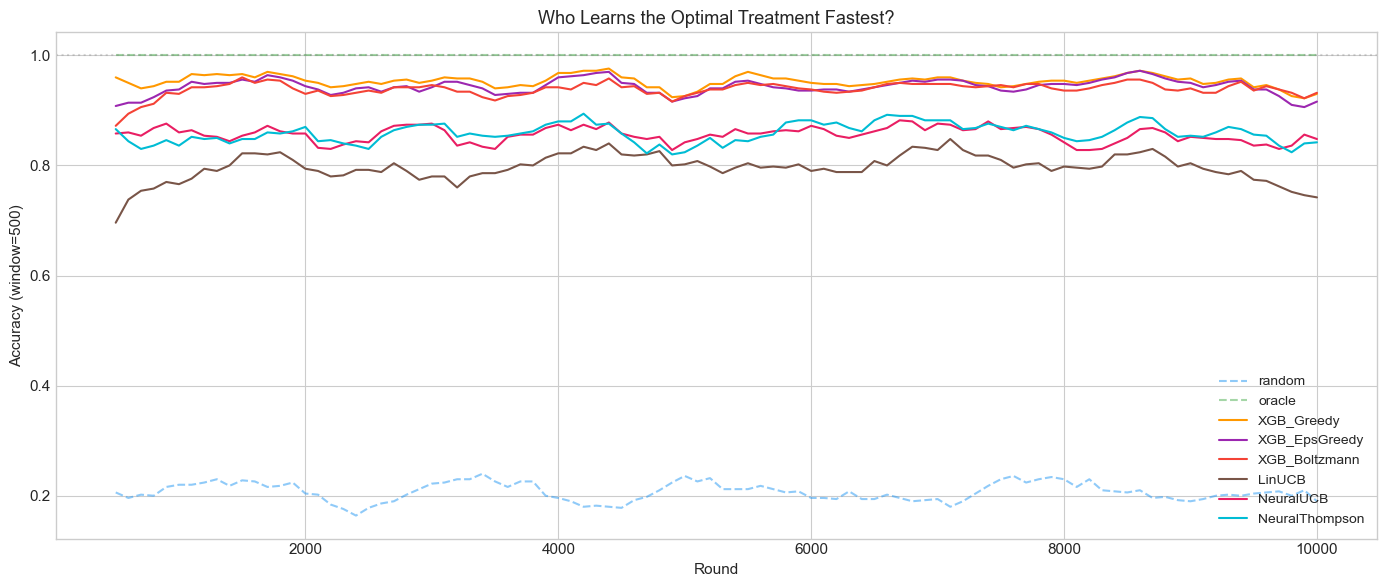

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

agent_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336',
                '#795548', '#E91E63', '#00BCD4', '#8BC34A']

for i, (name, w_df) in enumerate(windowed.items()):
    if name in ['random', 'oracle']:
        linestyle = '--'
        alpha = 0.5
    else:
        linestyle = '-'
        alpha = 1.0
    ax.plot(w_df['round'], w_df['accuracy'], label=name, linewidth=1.5,
            linestyle=linestyle, alpha=alpha, color=agent_colors[i % len(agent_colors)])

ax.set_xlabel("Round")
ax.set_ylabel("Accuracy (window=500)")
ax.set_title("Who Learns the Optimal Treatment Fastest?")
ax.legend(loc='lower right')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.3, label='perfect')

plt.tight_layout()
plt.show()

## Regret Decomposition — Per-Treatment Analysis

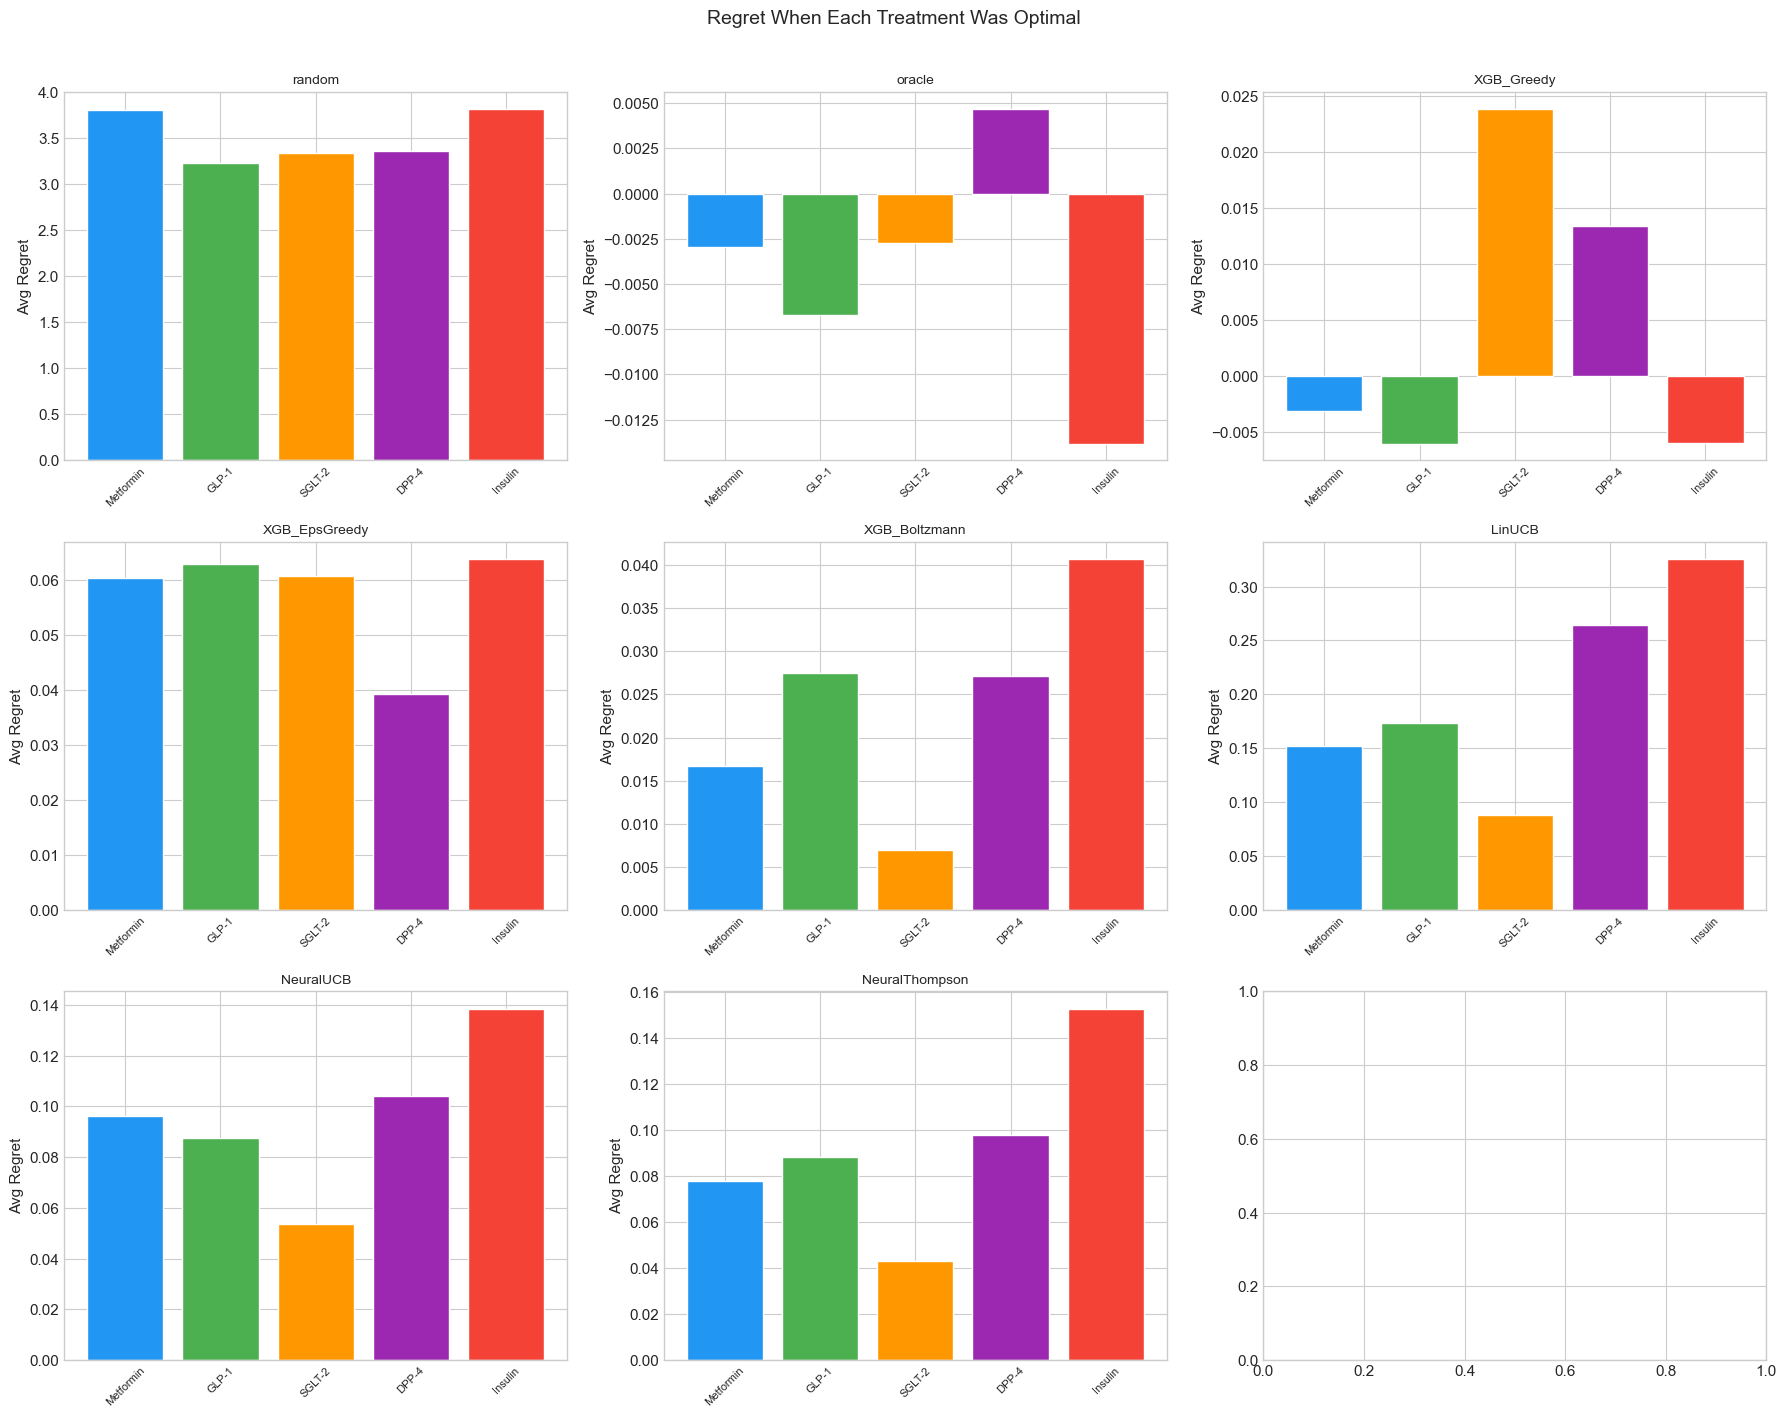

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (name, df_r) in enumerate(results.items()):
    if i >= 9:
        break
    ax = axes[i]

    actions = np.array(df_r['action'])
    optimal = np.array(df_r['optimal_action'])
    regrets = np.array(df_r['regret'])

    # Per-treatment mean regret
    per_treatment_regret = []
    for k in range(N_TREATMENTS):
        mask = optimal == k  # when treatment k was optimal
        if mask.sum() > 0:
            per_treatment_regret.append(regrets[mask].mean())
        else:
            per_treatment_regret.append(0)

    colors = [TREATMENT_COLORS[t] for t in TREATMENTS]
    ax.bar(TREATMENTS, per_treatment_regret, color=colors, edgecolor='white')
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("Avg Regret")
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle("Regret When Each Treatment Was Optimal", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Head-to-Head — Final 2000 Rounds Performance

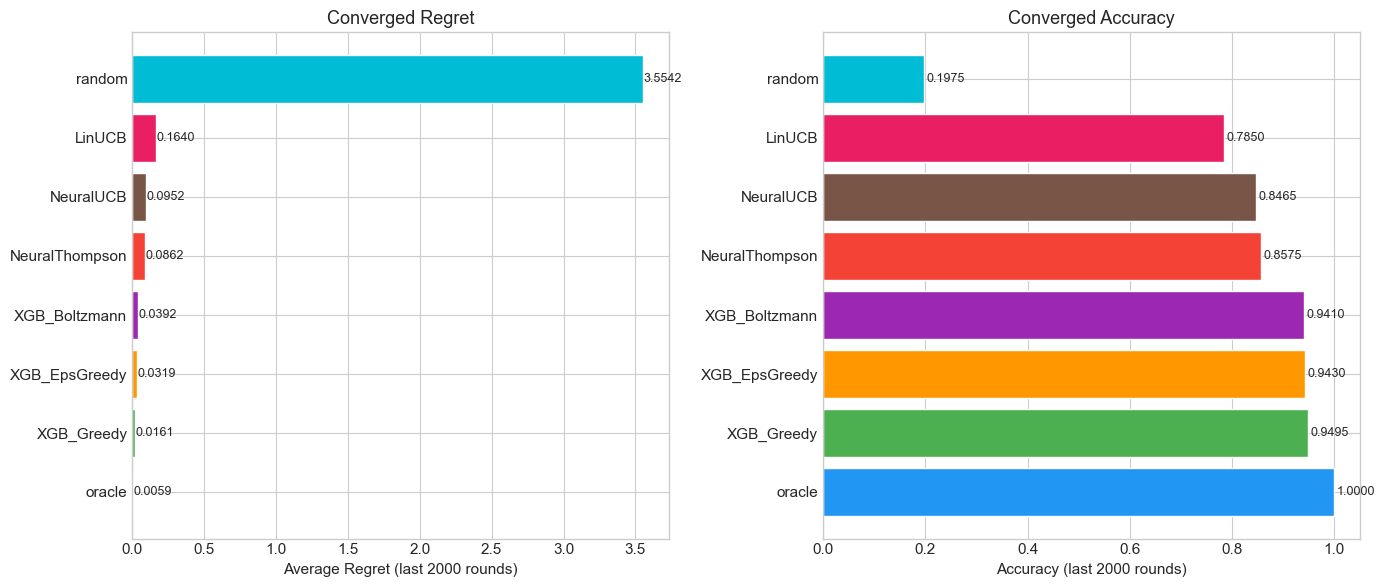

In [14]:
print("=" * 70)
print("FINAL 2000 ROUNDS PERFORMANCE (converged behavior)")
print("=" * 70)

late_stats = []
for name, df_r in results.items():
    late = df_r.tail(2000)
    late_stats.append({
        "agent": name,
        "avg_reward": round(late['reward'].mean(), 4),
        "avg_regret": round(late['regret'].mean(), 4),
        "accuracy": round(late['correct'].mean(), 4),
    })

late_df = pd.DataFrame(late_stats).sort_values("avg_regret")
print(late_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Sort by regret
late_df_sorted = late_df.sort_values('avg_regret', ascending=True)

colors = [agent_colors[i % len(agent_colors)] for i in range(len(late_df_sorted))]

ax1.barh(late_df_sorted['agent'], late_df_sorted['avg_regret'], color=colors, edgecolor='white')
ax1.set_xlabel("Average Regret (last 2000 rounds)")
ax1.set_title("Converged Regret")
for i, v in enumerate(late_df_sorted['avg_regret']):
    ax1.text(v + 0.005, i, f"{v:.4f}", va='center', fontsize=9)

ax2.barh(late_df_sorted['agent'], late_df_sorted['accuracy'], color=colors, edgecolor='white')
ax2.set_xlabel("Accuracy (last 2000 rounds)")
ax2.set_title("Converged Accuracy")
for i, v in enumerate(late_df_sorted['accuracy']):
    ax2.text(v + 0.005, i, f"{v:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Longer Simulation — 50,000 Rounds (Key Agents Only)

In [15]:
print("Running extended simulation (50,000 rounds)...")

# Rebuild fresh agents for clean comparison
seed_everything(123)

# Fresh LinUCB
linucb_long = LinUCBPolicy(feature_dim=input_dim, alpha=1.0)

long_agents = [
    make_random_agent(),
    make_linucb_agent("LinUCB", linucb_long),
    make_neural_bandit_agent("NeuralUCB", neural_ucb, pipe_scaled),
    make_neural_bandit_agent("NeuralThompson", neural_ts, pipe_scaled),
]

long_sim = OnlineSimulator(
    n_rounds=50000,
    pipeline=pipe_scaled,
    unscaled_pipeline=pipe_unscaled,
    seed=123,
    log_interval=10000,
)
for a in long_agents:
    long_sim.add_agent(a)

with timer("Long simulation (50k rounds)"):
    long_results = long_sim.run()

2026-03-14 21:08:45.501 | INFO     | src.utils:timer:437 - [TIMER] Long simulation (50k rounds): 1412.42s


## Long Simulation — Regret Curves

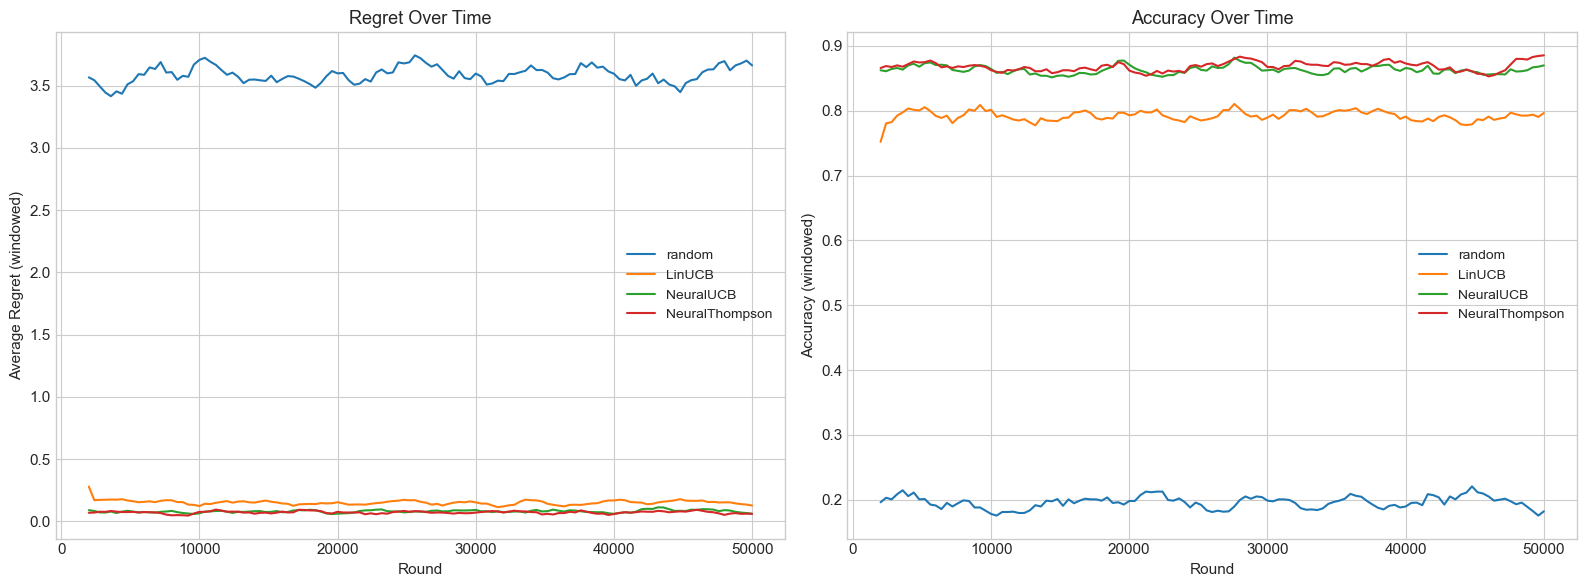

In [16]:
fig = plot_cumulative_regret(
    long_results,
    title="Cumulative Regret — 50,000 Rounds",
    save_path="../results/cumulative_regret_50k.png",
)
plt.show()

long_windowed = long_sim.get_windowed_metrics(window=2000)

fig = plot_regret_and_accuracy(
    long_windowed,
    save_path="../results/learning_curves_50k.png",
)
plt.show()

## Long Simulation — Summary

In [17]:
long_summary = long_sim.get_summary()
print("=" * 70)
print("50K ROUND SIMULATION SUMMARY")
print("=" * 70)
print(long_summary.to_string(index=False))

50K ROUND SIMULATION SUMMARY
         agent  total_reward  total_regret  avg_reward  avg_regret  accuracy  Metformin  GLP-1  SGLT-2  DPP-4  Insulin
NeuralThompson     297892.23       3528.19      5.9578      0.0706    0.8688     0.3088 0.1803  0.2636 0.1686   0.0787
     NeuralUCB     297455.49       3964.93      5.9491      0.0793    0.8632     0.3007 0.1859  0.2612 0.1717   0.0805
        LinUCB     293705.23       7715.19      5.8741      0.1543    0.7915     0.2927 0.1633  0.3189 0.1518   0.0733
        random     121893.41     179527.01      2.4379      3.5905    0.1956     0.2005 0.1981  0.2000 0.2003   0.2011


## Save All Results

In [18]:
save_results({
    "summary_10k": summary.to_dict(orient='records'),
    "late_performance_10k": late_df.to_dict(orient='records'),
    "summary_50k": long_summary.to_dict(orient='records'),
}, path="../results/online_simulation_results.json")

# Save per-round data for later analysis
for name, df_r in results.items():
    df_r.to_csv(f"../results/online_{name}.csv", index=False)

print("Results saved to ../results/")

Results saved to ../results/


##  Summary

In [19]:
print("=" * 70)
print("ONLINE SIMULATION SUMMARY")
print("=" * 70)

print("\n10K Rounds — Top 3 (by converged regret):")
top3 = late_df.head(3)
for _, row in top3.iterrows():
    if row['agent'] == 'oracle':
        continue
    print(f"  {row['agent']:<25} regret={row['avg_regret']:.4f}  accuracy={row['accuracy']:.4f}")

print(f"\n50K Rounds — Final Summary:")
for _, row in long_summary.iterrows():
    print(f"  {row['agent']:<25} total_regret={row['total_regret']:>8.1f}  accuracy={row['accuracy']:.4f}")

print(f"\n  Key insight: Watch how exploration agents (UCB, Thompson, LinUCB)")
print(f"  converge to lower regret over time while greedy agents plateau.")
print(f"\n  Next step: 06_offline_evaluation.ipynb")
print("=" * 70)

ONLINE SIMULATION SUMMARY

10K Rounds — Top 3 (by converged regret):
  XGB_Greedy                regret=0.0161  accuracy=0.9495
  XGB_EpsGreedy             regret=0.0319  accuracy=0.9430

50K Rounds — Final Summary:
  NeuralThompson            total_regret=  3528.2  accuracy=0.8688
  NeuralUCB                 total_regret=  3964.9  accuracy=0.8632
  LinUCB                    total_regret=  7715.2  accuracy=0.7915
  random                    total_regret=179527.0  accuracy=0.1956

  Key insight: Watch how exploration agents (UCB, Thompson, LinUCB)
  converge to lower regret over time while greedy agents plateau.

  Next step: 06_offline_evaluation.ipynb
